### ***Reading data and understanding it***

In [82]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [83]:
data = pd.read_csv('london_weather.csv')
data.head(5)

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


In [85]:
data.drop(columns=['date']).describe() #the date col is still a raw data until now 

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,15322.000000,15341.000000,15322.000000,15335.000000,15305.000000,15339.000000,15335.000000,15337.000000,13900.000000
mean,5.268242,4.350238,118.756951,15.388777,11.475511,7.559867,1.668634,101536.605594,0.037986
std,2.070072,4.028339,88.898272,6.554754,5.729709,5.326756,3.738540,1049.722604,0.545633
min,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000,0.000000,100920.000000,0.000000
50%,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000,0.000000,101620.000000,0.000000
75%,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000,1.600000,102240.000000,0.000000
max,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000,61.800000,104820.000000,22.000000


In [86]:
data.columns

Index(['date', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp',
       'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth'],
      dtype='object')

In [87]:
print (f'the total number of rows :{data.shape[0]}')

the total number of rows :15341


In [ ]:
#does the sunshine had any relartion with the temp , cloud cover ? -> heatmap after cleaning 
#converting date into datatime using pandas 
#filling nulls , discovering outliers 
#dicovering seasonality , trends , cyclicity (repeated pattern with no fixed period ), irregularity  
#divide date into year , month , day 

### ***Converting into datetime format***

In [88]:
#adjusting date data type to be in a datetime format 
# data['date_modif'] = pd.to_datetime(data['date']) #trying on a copy of the col
# data.head() ->valid conversion
# data.drop(columns=['date_modif'] , inplace = True )
data['date'] = pd.to_datetime(data['date'] , format = '%Y%m%d') #intializing the format is sooo important 
data['year'] = data['date'].dt.year 
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day


In [89]:
data.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth,year,month,day
0,1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0,1979,1,1
1,1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0,1979,1,2
2,1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0,1979,1,3
3,1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0,1979,1,4
4,1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0,1979,1,5


In [90]:
print (f'the total number of rows :{data.shape[0]}')

the total number of rows :15341


### ***HANDELING MISSING VALUES***

In [91]:
data.isna().sum()

date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
year                   0
month                  0
day                    0
dtype: int64

In [92]:
#inspecting the null values
rows_with_nulls = data[data.isnull().any(axis=1)]
print(f"Total rows with nulls: {len(rows_with_nulls)}")
print(f"That's {len(rows_with_nulls)/len(data)*100:.1f}% of your data")

# Show first 10 rows with nulls
print("\nFirst 10 rows containing null values:")
rows_with_nulls.head(5)

Total rows with nulls: 1498
That's 9.8% of your data

First 10 rows containing null values:


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth,year,month,day
14,1979-01-15,NaN,0.0,15.0,5.9,3.8,1.0,0.1,102990.0,0.0,1979,1,15
20,1979-01-21,NaN,0.0,16.0,1.5,0.0,-3.5,0.1,102170.0,0.0,1979,1,21
37,1979-02-07,NaN,0.0,21.0,3.7,3.3,-0.2,0.4,99450.0,0.0,1979,2,7
50,1979-02-20,NaN,0.0,27.0,3.6,1.6,0.3,0.0,103010.0,0.0,1979,2,20
56,1979-02-26,NaN,4.2,82.0,8.9,1.6,-3.4,0.0,103590.0,0.0,1979,2,26


In [ ]:
#filling nulls but each col with a specific format 
#cloud cover an dthe global radiation , snow depth -> median as iam dealing with time series data 
#means that i want to discover pattern so i will see the most repeated pattern in each column and filling the nulls with it 


# 1- filling on a copy of the data to avoid destroying data if something has went wrong 
# all data columns in "number data type so i don't have to select the numeric cols" and writing this line of code
#numeric_cols = df_filled.select_dtypes(include=[np.number]).columns
#numeric_cols = [col for col in numeric_cols if col != 'date']  # Skip date if numeric

# ****METHODS OF FILLING****
#in col like [cloud cover , sunshine , global radiation , snowdepth] -> median 
#for col like [max_temp , min_temp] based on deep learning with python book by the common sense method 
#the tommorow's temp will be too close to yesterday's temp -> ffill (forward fill)
#which is called -> ('temporal autocorrelation')
#in col like [mean_temp ] -> filling it after filling the max_temp and the min_temp("average of extremes" method)
#getting the avg between the extremes to fill the values of the mean 


#percipitation col 
# fill with 0 (simplest & often correct)
# why ? Most days have 0 precipitation in London

### ***TESTING STARTIGIES***

In [93]:
# Cell: Test temporal correlation in your London data
print("=== TESTING TEMPORAL CORRELATION ===")

# Sort by date first
df_sorted = data.sort_values('date').reset_index(drop=True)

# Calculate autocorrelation (lag=1 means yesterday)
for col in ['max_temp', 'min_temp', 'mean_temp']:
    if col in df_sorted.columns:
        # Drop nulls for correlation calculation
        temp_series = df_sorted[col].dropna()
        
        if len(temp_series) > 1:
            # Create yesterday's temperature (shift by 1 day)
            yesterday = temp_series.shift(1)
            today = temp_series
            
            # Calculate correlation
            correlation = today.corr(yesterday)
            
            print(f"{col}:")
            print(f"  Correlation with yesterday: {correlation:.3f}")
            
            if correlation > 0.7:
                print(f"  ✅ STRONG correlation! ffill is excellent")
            elif correlation > 0.5:
                print(f"  👍 MODERATE correlation! ffill is good")
            else:
                print(f"  ⚠️ WEAK correlation! Consider alternatives")
            
            # Show example
            if len(temp_series) > 10:
                print(f"  Example: If yesterday = {temp_series.iloc[10]:.1f}°C")
                print(f"          Today likely = {temp_series.iloc[11]:.1f}°C")
                print(f"          (Actual: {temp_series.iloc[11]:.1f}°C)")
            print()

=== TESTING TEMPORAL CORRELATION ===
max_temp:
  Correlation with yesterday: 0.926
  ✅ STRONG correlation! ffill is excellent
  Example: If yesterday = 2.9°C
          Today likely = 2.0°C
          (Actual: 2.0°C)

min_temp:
  Correlation with yesterday: 0.865
  ✅ STRONG correlation! ffill is excellent
  Example: If yesterday = 0.3°C
          Today likely = -2.0°C
          (Actual: -2.0°C)

mean_temp:
  Correlation with yesterday: 0.941
  ✅ STRONG correlation! ffill is excellent
  Example: If yesterday = 2.6°C
          Today likely = 0.4°C
          (Actual: 0.4°C)



In [94]:
#applying stratigies 
#firstly filling cols that needs to be filled with median 
# then min , max temp with the ffill method 
# then the mean temp but it has num of nulls more than min , max so i will use the avg of extremes to be more accurate 

cols_with_median = ['cloud_cover','global_radiation' ,'snow_depth']
cols_with_ffill = ['min_temp' , 'max_temp' , 'pressure']

data['precipitation'] = data['precipitation'].fillna(0) 

for col in cols_with_median:
    data[col] = data[col].fillna(data[col].median())

for col in cols_with_ffill:
    data[col] = data[col].ffill().bfill()



# Create mask: WHERE mean_temp IS NULL AND we have both max_temp AND min_temp
condition = (
    data['mean_temp'].isnull() &           # mean_temp is missing
    data['max_temp'].notnull() &           # max_temp exists  
    data['min_temp'].notnull()             # min_temp exists
)

# Count how many rows meet the condition
rows_to_fill = condition.sum()
print(f"Rows that can be filled with (max+min)/2: {rows_to_fill}")

# Apply your formula ONLY to these rows
if rows_to_fill > 0:
    data.loc[condition, 'mean_temp'] = (
        data.loc[condition, 'max_temp'] + 
        data.loc[condition, 'min_temp']
    ) / 2

Rows that can be filled with (max+min)/2: 36


In [95]:
data.isna().sum()

date                0
cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
precipitation       0
pressure            0
snow_depth          0
year                0
month               0
day                 0
dtype: int64

### ***Data Validation***

In [96]:
# Checking 
wrong_rows = (data['max_temp'] < data['min_temp']).sum()
print(f"Rows where max_temp < min_temp: {wrong_rows}")

Rows where max_temp < min_temp: 230


In [97]:
# Find and display the problematic rows
problematic = data[data['max_temp'] < data['min_temp']]
print(f"Found {len(problematic)} rows where max_temp < min_temp:")

if len(problematic) > 0:
    print(problematic[['date', 'max_temp', 'min_temp']].head())

Found 230 rows where max_temp < min_temp:
          date  max_temp  min_temp
15  1979-01-16       2.6       4.1
43  1979-02-13       0.2       0.3
44  1979-02-14      -0.8      -0.7
71  1979-03-13       3.8       4.4
474 1980-04-19       9.1       9.4


In [98]:
#solution ? 
#if few means swapping (simplest one)
#if many -> using interpolation

problematic = data[data['max_temp'] < data['min_temp']]
max_diff = (problematic['min_temp'] - problematic['max_temp']).max()

if max_diff < 2.0:  # Less than 2°C difference
        print(f"Max difference is only {max_diff:.1f}°C")
        print(" SAFE to swap - likely measurement errors")
else:
        print(f"Large differences up to {max_diff:.1f}°C detected")
        print(" Investigate data source or use interpolation")

Large differences up to 6.8°C detected
 Investigate data source or use interpolation


In [99]:
# 1. Mark bad rows as NaN
mask = data['max_temp'] < data['min_temp']
data.loc[mask, ['max_temp', 'min_temp']] = np.nan

# 2. Interpolate
data['max_temp'] = data['max_temp'].interpolate()
data['min_temp'] = data['min_temp'].interpolate()

In [100]:
# Checking 
wrong_rows = (data['max_temp'] < data['min_temp']).sum()
print(f"Rows where max_temp < min_temp: {wrong_rows}")

Rows where max_temp < min_temp: 0


### ***OUTLIERS***

In [101]:
# ONE CELL - Complete outlier detection for temperatures
print("=== TEMPERATURE OUTLIER DETECTION ===")

# Function to detect outliers using IQR method
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers, lower_bound, upper_bound

# Check each temperature column
for col in ['max_temp', 'mean_temp', 'min_temp']:
    if col in data.columns:
        print(f"\n📈 {col.upper()}:")
        
        outliers, lower, upper = detect_outliers_iqr(data[col])
        outlier_count = outliers.sum()
        
        print(f"  Lower bound: {lower:.1f}°C")
        print(f"  Upper bound: {upper:.1f}°C")
        print(f"  Actual range: [{data[col].min():.1f}, {data[col].max():.1f}]°C")
        print(f"  Outliers found: {outlier_count} ({outlier_count/len(data)*100:.1f}%)")
        
        # Show extreme outliers
        if outlier_count > 0:
            extreme = data[outliers][col]
            print(f"  Most extreme: {extreme.min():.1f}°C to {extreme.max():.1f}°C")

=== TEMPERATURE OUTLIER DETECTION ===

📈 MAX_TEMP:
  Lower bound: -4.0°C
  Upper bound: 34.9°C
  Actual range: [-3.3, 37.9]°C
  Outliers found: 12 (0.1%)
  Most extreme: 35.0°C to 37.9°C

📈 MEAN_TEMP:
  Lower bound: -6.3°C
  Upper bound: 29.4°C
  Actual range: [-7.6, 29.0]°C
  Outliers found: 1 (0.0%)
  Most extreme: -7.6°C to -7.6°C

📈 MIN_TEMP:
  Lower bound: -8.8°C
  Upper bound: 24.0°C
  Actual range: [-11.8, 22.3]°C
  Outliers found: 7 (0.0%)
  Most extreme: -11.8°C to -8.9°C


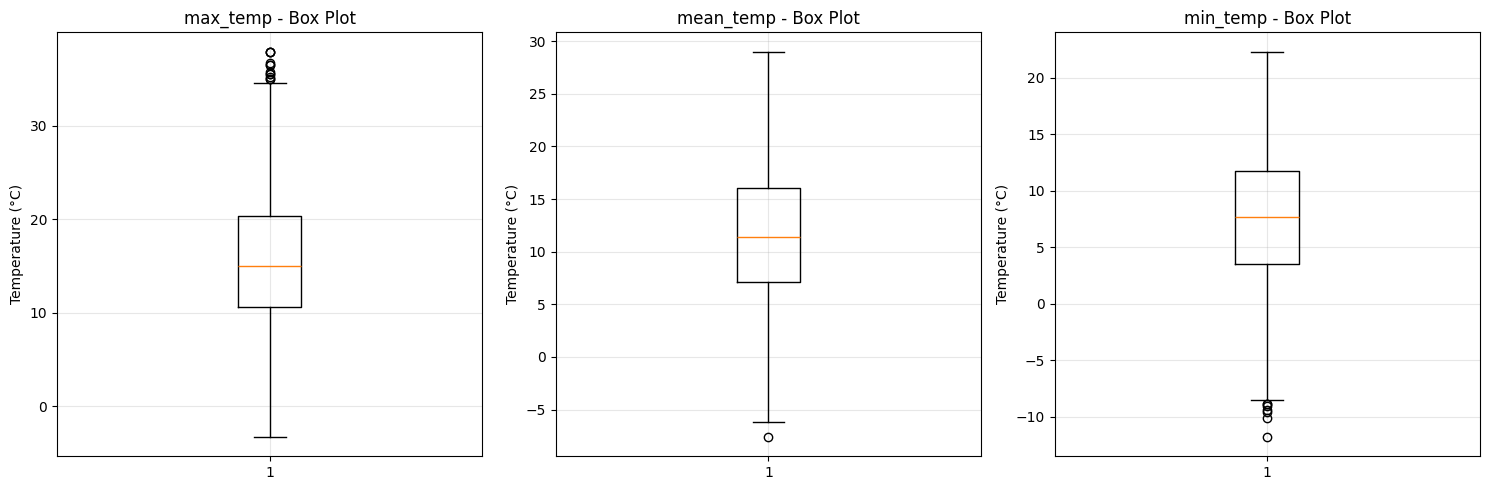

📊 Box plots show: Whiskers = normal range, Dots outside = outliers


In [102]:
# SIMPLE BOX PLOTS for outliers
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(['max_temp', 'mean_temp', 'min_temp']):
    if col in data.columns:
        axes[idx].boxplot(data[col].dropna())
        axes[idx].set_title(f'{col} - Box Plot')
        axes[idx].set_ylabel('Temperature (°C)')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Box plots show: Whiskers = normal range, Dots outside = outliers")

In [ ]:
#too few percentage for the data it may means that there are some days really has an extremes in their temprature 
#after searching on time series analysis i found out that there is somthing called irregularity means sudden changes 
#in the weather 

In [103]:
maxi = data['max_temp'].max()
maxi_mean = data['mean_temp'].max()
maxi_min = data['min_temp'].max()
mini = data['max_temp'].min()
mini_mean = data['mean_temp'].min()
min_min = data['min_temp'].min()
print(f'the max of the max temprature :{maxi}')
print(f'the max of the mean temprature :{maxi_mean}')
print(f'the max of the min temprature :{maxi_min}')
print(f'the min of the max temprature :{mini}')
print(f'the min of the mean temprature :{mini_mean}')
print(f'the min of the min temprature :{min_min}')
#instead of all of this we can simply write data.describe
# i've just wrote them in print function to see them 'taht ba3d' 

the max of the max temprature :37.9
the max of the mean temprature :29.0
the max of the min temprature :22.3
the min of the max temprature :-3.3
the min of the mean temprature :-7.6
the min of the min temprature :-11.8


### ***saving data after cleaning and preprocessing***

In [104]:
data.to_csv('DATA_EST7AMET.csv', index=False)

### ***discovering seasonality , trends , correlation through correlation matrix***